# Analisa Data (A)

## Reproduksi Skforecast Explainability

Sumber tutorial:
https://skforecast.org/0.15.1/user_guides/explainability.html

# Pendahuluan

Forecasting merupakan teknik analisis yang digunakan untuk memprediksi nilai di masa depan berdasarkan data historis.

Pada tugas ini dilakukan reproduksi tutorial Explainability menggunakan library Skforecast dan algoritma LightGBM untuk memprediksi kebutuhan listrik harian di Victoria, Australia.

Selain menghasilkan prediksi, penelitian ini juga bertujuan memahami faktor-faktor yang memengaruhi hasil prediksi menggunakan metode Explainable AI (XAI).

## Tujuan
Mereproduksi contoh *Model Explainability* pada Skforecast untuk memahami:
- Prediksi kebutuhan listrik.
- Penggunaan lag pada time series forecasting.
- Feature Importance.
- SHAP Values.
- Permutation Importance.
- Partial Dependence Plot.

# Install Library

```bash
pip install skforecast lightgbm shap -q
```

# Import Library

Library yang digunakan meliputi:

- Pandas
- Matplotlib
- SHAP
- LightGBM
- Skforecast

Library tersebut digunakan untuk pengolahan data, visualisasi, forecasting, dan explainability.

In [27]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

# Pengambilan Dataset

Dataset yang digunakan adalah vic_electricity yang berisi data konsumsi listrik dan suhu di Victoria, Australia.

Variabel utama:

- Demand
- Temperature

In [28]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


# Eksplorasi Dataset

In [29]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52608 entries, 2011-12-31 13:00:00 to 2014-12-31 12:30:00
Freq: 30min
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Demand       52608 non-null  float64
 1   Temperature  52608 non-null  float64
 2   Date         52608 non-null  object 
 3   Holiday      52608 non-null  bool   
dtypes: bool(1), float64(2), object(1)
memory usage: 1.7+ MB


,Demand,Temperature
count,52608.000000,52608.000000
mean,4665.432826,16.265071
std,874.273645,5.658849
min,2857.945728,1.500000
25%,3969.464472,12.300000
50%,4634.706032,15.400000
75%,5244.325424,19.400000
max,9345.004346,43.200000


## Interpretasi Statistik Deskriptif

Berdasarkan hasil statistik deskriptif yang diperoleh:

- Dataset hasil agregasi harian terdiri dari 1097 observasi.
- Rata-rata kebutuhan listrik harian sebesar 223.736 MW.
- Rata-rata suhu harian sebesar 16,27°C.
- Nilai minimum demand sebesar 82.531 MW dan maksimum mencapai 351.459 MW.
- Tidak ditemukan missing value pada variabel Demand maupun Temperature.

Berdasarkan informasi tersebut, dataset memiliki kualitas yang baik dan siap digunakan untuk proses forecasting.

# Preprocessing Data

In [30]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head()

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042
2012-01-03,258955.329422,24.567708
2012-01-04,213792.376946,18.191667


## Penjelasan

Data asli dicatat setiap 30 menit sehingga dilakukan agregasi harian.

- Demand → dijumlahkan
- Temperature → dirata-ratakan

Tujuannya untuk menyederhanakan proses forecasting.

# Visualisasi Data

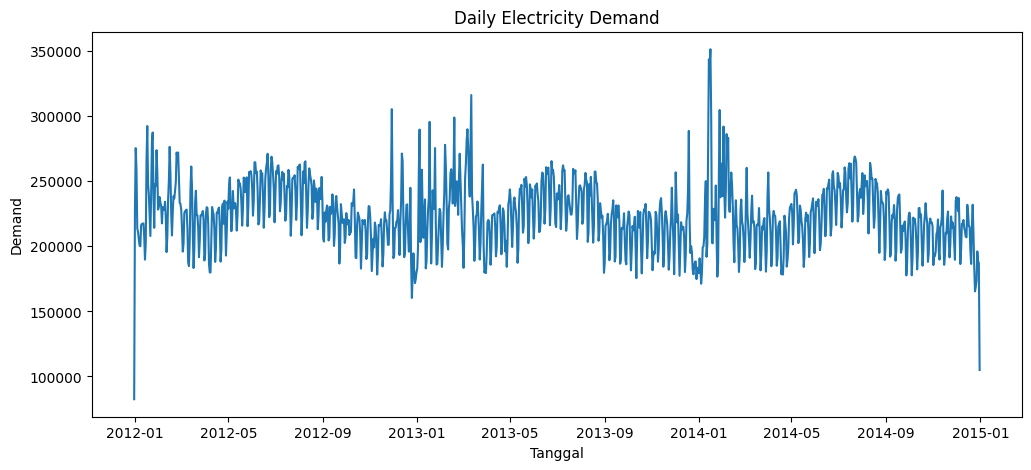

In [31]:
plt.figure(figsize=(12,5))
plt.plot(data["Demand"])
plt.title("Daily Electricity Demand")
plt.xlabel("Tanggal")
plt.ylabel("Demand")
plt.show()

## Interpretasi Visualisasi

Grafik menunjukkan adanya fluktuasi kebutuhan listrik harian.

Terlihat pola musiman yang menunjukkan bahwa data historis memiliki informasi yang cukup untuk digunakan dalam forecasting.

# Pembagian Data Training dan Testing

In [32]:
# Split train-test
# ==============================================================================
data_train = data.loc[:'2014-12-21']
data_test = data.loc['2014-12-22':]

print("Jumlah data train :", len(data_train))
print("Jumlah data test  :", len(data_test))

Jumlah data train : 1087
Jumlah data test  : 10


# Pembuatan Model Forecasting

In [33]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
        regressor = LGBMRegressor(random_state=123, verbose=-1),
        lags      = 7
    )

## Penjelasan Model

Model menggunakan:

- LightGBM
- ForecasterRecursive
- 7 lag historis

untuk memprediksi kebutuhan listrik harian.

# Training Model

In [34]:
forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-11 16:48:47 
Last fit date: 2026-06-11 16:48:47 
Skforecast version: 0.18.0 
Python version: 3.9.13 
Forecaster id: None

# Feature Importance

In [35]:
# Predictors importances
# ==============================================================================
feature_importance = forecaster.get_feature_importances()

feature_importance

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


## Interpretasi Feature Importance

Temperature dan lag_1 merupakan fitur yang paling berpengaruh terhadap prediksi kebutuhan listrik.

# SHAP Values

In [36]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
        y    = data_train['Demand'],
        exog = data_train['Temperature']
    )

display(X_train.head())
display(y_train.head())

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458
2012-01-10,216201.836844,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,16.042708
2012-01-11,217176.907910,216201.836844,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,14.815625


Time
2012-01-07    200693.270298
2012-01-08    200061.614738
2012-01-09    216201.836844
2012-01-10    217176.907910
2012-01-11    217517.475010
Freq: D, Name: y, dtype: float64

In [11]:
# Create SHAP explainer
# ==============================================================================
shap.initjs()
explainer = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer.shap_values(X_train)

SHAP Bar Plot

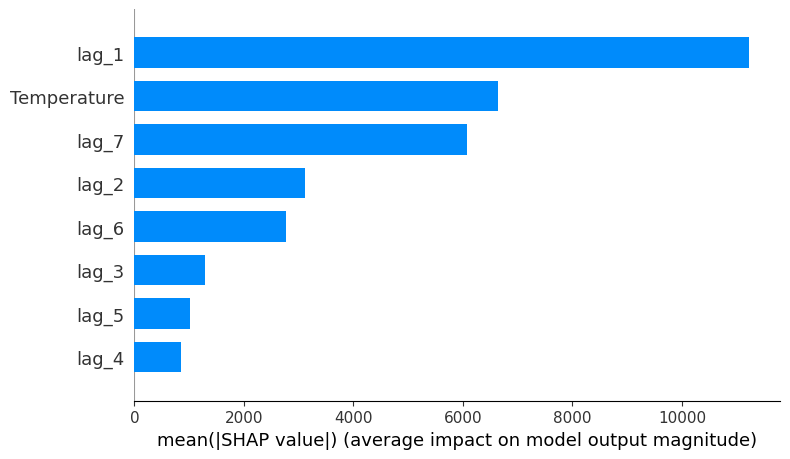

In [12]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

SHAP Summary Plot

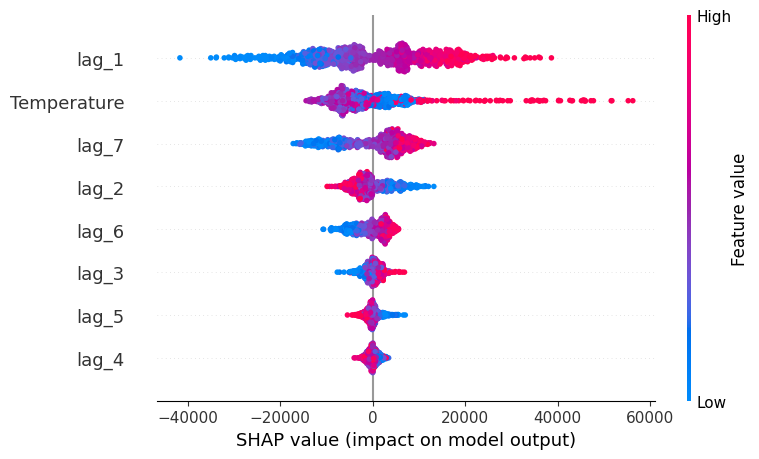

In [13]:
shap.summary_plot(shap_values, X_train)

## Interpretasi SHAP

SHAP menunjukkan bahwa Temperature dan lag_1 memiliki kontribusi terbesar terhadap hasil prediksi.

# Analisis Explainability Lanjutan

In [14]:
predictions = forecaster.predict(
    steps=10,
    exog=data_test["Temperature"]
)

predictions

2014-12-22    241514.532543
2014-12-23    226165.936559
2014-12-24    220506.468700
2014-12-25    209260.948991
2014-12-26    184885.145832
2014-12-27    195623.591810
2014-12-28    222766.340659
2014-12-29    223112.716406
2014-12-30    219103.891733
2014-12-31    217948.965404
Freq: D, Name: pred, dtype: float64

## 14. Input Prediksi

In [15]:
X_predict = forecaster.create_predict_X(
    steps=10,
    exog=data_test["Temperature"]
)

X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


In [16]:
r = permutation_importance(
    estimator=forecaster.regressor,
    X=X_train,
    y=y_train,
    n_repeats=3,
    max_samples=0.5,
    random_state=123
)

In [17]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'mean_importance': r.importances_mean,
    'std_importance': r.importances_std
}).sort_values(
    'mean_importance',
    ascending=False
)

importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


## Interpretasi Permutation Importance

Permutation Importance mengukur tingkat kepentingan fitur dengan cara mengacak nilai fitur dan melihat perubahan performa model.

Hasil menunjukkan bahwa:

- lag_1 merupakan fitur yang paling penting.
- Temperature memiliki kontribusi yang tinggi.
- lag_7 juga memberikan pengaruh terhadap model.

Hal ini menunjukkan bahwa informasi historis dan suhu merupakan faktor utama dalam forecasting kebutuhan listrik.

## 16. Partial Dependence Plot

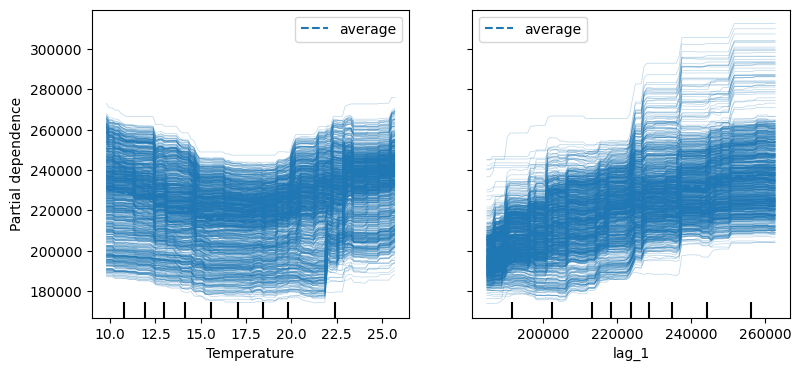

In [18]:
fig, ax = plt.subplots(
    figsize=(9,4)
)

PartialDependenceDisplay.from_estimator(
    estimator=forecaster.regressor,
    X=X_train,
    features=["Temperature","lag_1"],
    kind='both',
    ax=ax
)

plt.show()

# Analisis Explainability Lanjutan

Pada tahap ini dilakukan analisis lebih lanjut menggunakan SHAP Force Plot, SHAP Dependence Plot, dan Explainability Forecast.

Tujuannya adalah memahami kontribusi masing-masing fitur terhadap prediksi model baik secara global maupun individual.


In [19]:
# Force plot for the first observation
# ==============================================================================
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

## Interpretasi Prediksi Individual

Visualisasi ini menjelaskan faktor-faktor yang mempengaruhi satu prediksi tertentu.

Fitur dengan kontribusi positif meningkatkan hasil prediksi, sedangkan fitur dengan kontribusi negatif menurunkan hasil prediksi.

Dengan demikian alasan model menghasilkan suatu prediksi dapat dipahami secara lebih rinci.

In [20]:
# Force plot for the first 200 observations in the training set
# ==============================================================================
shap.force_plot(explainer.expected_value, shap_values[:200, :], X_train.iloc[:200, :])

## Interpretasi SHAP Force Plot

Visualisasi ini menjelaskan alasan model menghasilkan prediksi pada satu observasi tertentu.

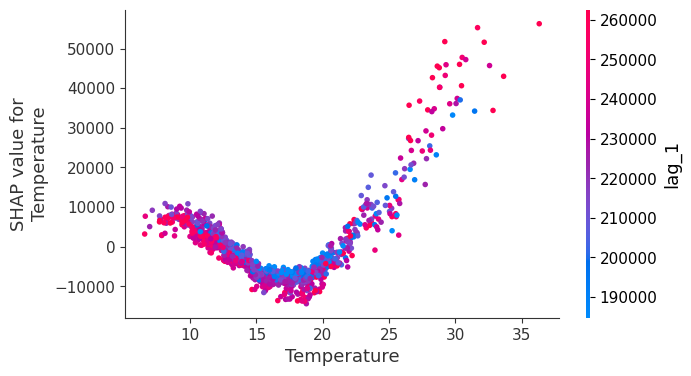

In [21]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)

## Interpretasi SHAP Dependence Plot

Perubahan Temperature memberikan pengaruh signifikan terhadap prediksi kebutuhan listrik.

In [22]:
# Predict
# ==============================================================================
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
predictions

2014-12-22    241514.532543
2014-12-23    226165.936559
2014-12-24    220506.468700
2014-12-25    209260.948991
2014-12-26    184885.145832
2014-12-27    195623.591810
2014-12-28    222766.340659
2014-12-29    223112.716406
2014-12-30    219103.891733
2014-12-31    217948.965404
Freq: D, Name: pred, dtype: float64

In [23]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


In [24]:
# Force plot for a specific prediction
# ==============================================================================
predicted_date = '2014-12-22'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)
shap_values = explainer.shap_values(X_predict)
shap.force_plot(
    explainer.expected_value,
    shap_values[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

In [25]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

# Permutation importances
# ==============================================================================
r = permutation_importance(
        estimator    = forecaster.regressor,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances = pd.DataFrame({
                  'feature': X_train.columns,
                  'mean_importance': r.importances_mean,
                  'std_importance': r.importances_std
              }).sort_values('mean_importance', ascending=False)
importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


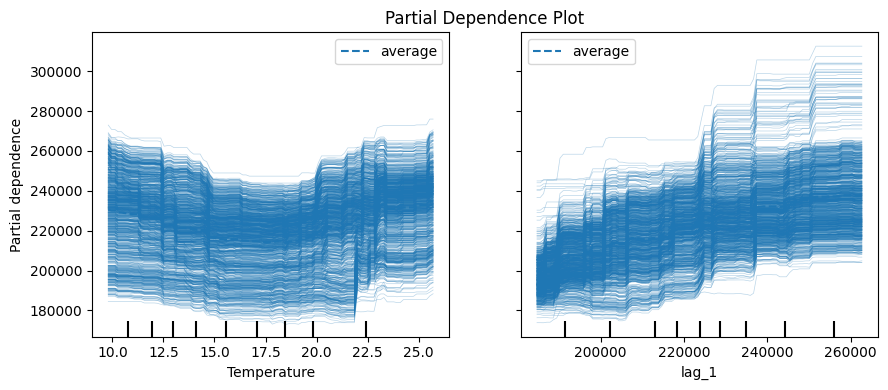

In [26]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Partial Dependence Plot")
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.regressor,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout();

## Interpretasi Partial Dependence Plot

Partial Dependence Plot menunjukkan hubungan antara fitur dan hasil prediksi.

Pada fitur Temperature terlihat bahwa perubahan suhu mempengaruhi kebutuhan listrik secara signifikan.

Pada fitur lag_1 terlihat bahwa peningkatan konsumsi listrik pada hari sebelumnya cenderung meningkatkan prediksi kebutuhan listrik pada hari berikutnya.

## Interpretasi SHAP Dependence Plot

SHAP Dependence Plot digunakan untuk melihat hubungan antara nilai suatu fitur dengan kontribusinya terhadap prediksi.

Pada fitur Temperature terlihat bahwa perubahan suhu memberikan pengaruh yang signifikan terhadap kebutuhan listrik. Hal ini menunjukkan bahwa temperatur merupakan salah satu faktor utama yang digunakan model dalam menghasilkan prediksi.


# Kesimpulan

Tugas ini mereproduksi tutorial explainability dari Skforecast dengan model LightGBM untuk memprediksi kebutuhan listrik harian di Victoria, Australia. Hasil analisis menunjukkan bahwa fitur yang paling berpengaruh terhadap prediksi adalah Temperature dan lag_1. Penjelasan model diperoleh melalui Feature Importance, SHAP Values, Permutation Importance, dan Partial Dependence Plot.

## Jawaban Pertanyaan Tugas

### 1. Analisis prediksi yang dilakukan
Prediksi yang dilakukan dalam studi kasus ini adalah prediksi kebutuhan listrik harian (electricity demand) di wilayah Victoria, Australia. Tujuan prediksi ini adalah untuk mendukung perencanaan distribusi energi dan pengambilan keputusan terkait pasokan listrik. Dengan kata lain, model digunakan untuk memperkirakan jumlah konsumsi listrik pada hari berikutnya agar pihak pengelola dapat merencanakan pembangkitan dan distribusi secara lebih efisien.

### 2. Bentuk data training
Data yang digunakan merupakan data deret waktu (time series) yang diubah menjadi bentuk supervised learning. Variabel input model (X) terdiri atas nilai demand beberapa hari sebelumnya, yaitu lag_1 sampai lag_7, serta suhu harian (Temperature). Variabel output model (y) adalah nilai demand pada hari berikutnya. Dengan demikian, model belajar pola hubungan antara konsumsi listrik masa lalu dan kondisi suhu terhadap konsumsi listrik yang akan datang.

Secara sederhana, model mempelajari hubungan sebagai berikut:
Demand(t) = f(lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag_7, Temperature)

Contoh sederhana bentuk data training:

| lag_1 | lag_2 | lag_3 | lag_4 | lag_5 | lag_6 | lag_7 | Temperature |
|--------|--------|--------|--------|--------|--------|--------|--------|
|205338|211066|213792|258955|275490|227778|82531|24.09|

Output (y):

| Demand |
|--------|
|200693|

### 3. Pengertian lag
Lag adalah nilai historis dari suatu variabel pada periode sebelumnya yang digunakan sebagai masukan untuk memprediksi nilai pada periode berikutnya. Dalam konteks ini, lag_1 berarti konsumsi listrik satu hari sebelumnya, lag_2 berarti dua hari sebelumnya, dan seterusnya hingga lag_7 yang merepresentasikan data satu minggu sebelumnya. Penggunaan lag penting karena pola konsumsi listrik sering dipengaruhi oleh kebiasaan penggunaan pada hari-hari sebelumnya.

### 4. Proses analisis yang dilakukan
Proses analisis diawali dengan pengambilan data `vic_electricity`, kemudian data yang semula tercatat setiap 30 menit diaggregasi menjadi data harian. Langkah ini dilakukan agar pola harian lebih mudah diamati dan sesuai dengan tujuan prediksi jangka pendek. Selanjutnya, data dibagi menjadi data training dan testing, lalu model `ForecasterRecursive` dengan algoritma LightGBM digunakan untuk memprediksi demand selama 10 hari ke depan.

Setelah model terbentuk, dilakukan analisis explainability melalui Feature Importance, SHAP Values, Permutation Importance, dan Partial Dependence Plot. Tujuan dari tahapan ini adalah untuk mengetahui fitur mana yang paling berpengaruh terhadap hasil prediksi serta memahami alasan model menghasilkan nilai prediksi tertentu. Hasil analisis menunjukkan bahwa kebutuhan listrik harian sangat dipengaruhi oleh konsumsi listrik sebelumnya dan kondisi suhu lingkungan. Dengan demikian, model tidak hanya mampu menghasilkan prediksi, tetapi juga menjelaskan faktor-faktor yang paling berpengaruh terhadap hasil prediksi.

Proses analisis dilakukan melalui tahapan berikut:

1. Mengambil dataset `vic_electricity`.
2. Melakukan agregasi data dari interval 30 menit menjadi harian.
3. Membagi data menjadi training dan testing.
4. Melatih model `ForecasterRecursive` menggunakan algoritma LightGBM.
5. Menggunakan 7 lag historis dan Temperature sebagai fitur.
6. Melakukan Feature Importance Analysis.
7. Melakukan SHAP Analysis.
8. Melakukan Forecasting selama 10 hari ke depan.
9. Menghitung Permutation Importance.
10. Membuat Partial Dependence Plot.
11. Menarik kesimpulan berdasarkan hasil explainability.